# Sentiment Overlay Backtest

Notebook ini mengecek satu hal: apakah overlay news dari pipeline sentiment punya pola yang cukup berguna terhadap return harga jangka pendek.

Fokus notebook:
- hanya memakai hasil backfill historis news
- tidak menyentuh notebook utama XGBoost
- membandingkan hari dengan overlay news vs benchmark semua hari trading
- membedakan pembacaan `bullish` dan `bearish`


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

BACKFILL_PREFIX = "gdelt_backfill_180d_english_v2"

OVERLAY_PATH = ROOT / f"data/news/features/{BACKFILL_PREFIX}_overlay_signals.csv"
DAILY_PATH = ROOT / f"data/news/features/{BACKFILL_PREFIX}_daily_sentiment.csv"
SCORED_PATH = ROOT / f"data/news/scored/{BACKFILL_PREFIX}_candidate_model_scored.csv"
PRICE_PATH = ROOT / "data/raw data/ali_f_raw.csv"

overlay = pd.read_csv(OVERLAY_PATH)
daily = pd.read_csv(DAILY_PATH)
scored = pd.read_csv(SCORED_PATH)
price = pd.read_csv(PRICE_PATH)

overlay["news_date"] = pd.to_datetime(overlay["news_date"])
daily["news_date"] = pd.to_datetime(daily["news_date"])
scored["news_date"] = pd.to_datetime(scored["news_date"])
scored["news_datetime"] = pd.to_datetime(scored["news_datetime"], errors="coerce")
price["Date"] = pd.to_datetime(price["Date"])
price = price.sort_values("Date").reset_index(drop=True)

overlay = overlay.sort_values("news_date").reset_index(drop=True)
daily = daily.sort_values("news_date").reset_index(drop=True)
scored = scored.sort_values(["news_date", "news_datetime"]).reset_index(drop=True)


## Ringkasan Dataset

Bagian ini memastikan dulu ukuran data yang sedang diuji. Tujuannya supaya pembacaan hasil tidak overclaim.


In [2]:
overview = pd.DataFrame(
    [
        {"Bagian": "Artikel candidate_model terscore", "Jumlah": len(scored)},
        {"Bagian": "Hari sentiment harian", "Jumlah": len(daily)},
        {"Bagian": "Hari overlay", "Jumlah": len(overlay)},
        {"Bagian": "Rentang news", "Jumlah": f"{overlay['news_date'].min().date()} -> {overlay['news_date'].max().date()}"},
        {"Bagian": "Rentang harga", "Jumlah": f"{price['Date'].min().date()} -> {price['Date'].max().date()}"},
    ]
)
display(overview)

overlay_counts = (
    overlay["overlay_role"]
    .value_counts(dropna=False)
    .rename_axis("overlay_role")
    .reset_index(name="hari")
)
label_counts = (
    scored["impact_label"]
    .value_counts(dropna=False)
    .rename_axis("impact_label")
    .reset_index(name="artikel")
)

print("Distribusi overlay role")
display(overlay_counts)
print("Distribusi label artikel")
display(label_counts)


,Bagian,Jumlah
0,Artikel candidate_model terscore,38
1,Hari sentiment harian,30
2,Hari overlay,30
3,Rentang news,2025-09-22 -> 2026-03-09
4,Rentang harga,2014-05-06 -> 2026-03-04


Distribusi overlay role


,overlay_role,hari
0,ignore,10
1,bullish_watch,8
2,bullish_conviction,6
3,bearish_watch,5
4,watchlist,1


Distribusi label artikel


,impact_label,artikel
0,bullish,20
1,bearish,10
2,neutral,8


## Join ke Harga dan Return Masa Depan

Setiap `news_date` dipetakan ke hari trading yang sama atau hari trading berikutnya. Setelah itu dihitung return `T+1`, `T+3`, dan `T+5`.


In [3]:
price_eval = price[["Date", "Close"]].copy()
price_eval["ret_t1_pct"] = price_eval["Close"].shift(-1) / price_eval["Close"] - 1.0
price_eval["ret_t3_pct"] = price_eval["Close"].shift(-3) / price_eval["Close"] - 1.0
price_eval["ret_t5_pct"] = price_eval["Close"].shift(-5) / price_eval["Close"] - 1.0
price_eval["day_return_pct"] = price_eval["Close"].pct_change(fill_method=None)

evaluation = pd.merge_asof(
    overlay.sort_values("news_date"),
    price_eval.sort_values("Date"),
    left_on="news_date",
    right_on="Date",
    direction="forward",
).rename(columns={"Date": "anchor_trade_date"})

evaluation["expected_sign"] = np.where(
    evaluation["overlay_bias"].eq("bullish"),
    1,
    np.where(evaluation["overlay_bias"].eq("bearish"), -1, np.nan),
)

for horizon in [1, 3, 5]:
    col = f"ret_t{horizon}_pct"
    evaluation[f"dir_correct_t{horizon}"] = np.where(
        evaluation["expected_sign"].notna() & evaluation[col].notna(),
        np.sign(evaluation[col]) == evaluation["expected_sign"],
        np.nan,
    )

view_cols = [
    "news_date",
    "anchor_trade_date",
    "overlay_role",
    "overlay_bias",
    "overlay_strength",
    "dominant_channel",
    "news_count_model",
    "market_sentiment_mean",
    "ret_t1_pct",
    "ret_t3_pct",
    "ret_t5_pct",
]
display(evaluation[view_cols])


,news_date,anchor_trade_date,overlay_role,overlay_bias,overlay_strength,dominant_channel,news_count_model,market_sentiment_mean,ret_t1_pct,ret_t3_pct,ret_t5_pct
0,2025-09-22,2025-09-22,bullish_watch,bullish,medium,supply,1,0.60,-0.003261,0.008201,0.021045
1,2025-10-04,2025-10-06,ignore,neutral_or_hold,weak,supply,1,0.20,0.009768,0.034708,0.006543
2,2025-10-07,2025-10-07,ignore,neutral_or_hold,weak,macro,1,0.00,0.007231,-0.021976,-0.009767
3,2025-10-13,2025-10-13,bullish_conviction,bullish,strong,supply,1,0.70,-0.006595,0.012342,0.013473
4,2025-10-15,2025-10-15,bearish_watch,bearish,medium,logistics,1,-0.30,0.016364,0.017499,0.024593
5,2025-10-22,2025-10-22,bullish_watch,bullish,medium,policy,1,0.60,0.022434,0.034066,0.044775
6,2025-10-24,2025-10-24,ignore,neutral_or_hold,weak,price,2,-0.20,0.008463,0.018907,0.017286
7,2025-10-31,2025-10-31,bearish_watch,bearish,strong,demand,1,-0.70,0.009735,-0.021949,-0.017612
8,2025-11-11,2025-11-11,bullish_watch,bullish,strong,policy,1,0.90,0.010678,0.000179,-0.036612
9,2025-11-12,2025-11-12,bullish_watch,bullish,strong,policy,1,0.90,0.005061,-0.029655,-0.036314


## Ringkasan Overlay vs Benchmark

Di sini ada dua pembacaan:
- **overlay by role**: bagaimana return rata-rata dan ketepatan arah per jenis overlay
- **benchmark**: bagaimana return rata-rata semua hari trading pada periode yang sama


In [4]:

def summarize_overlay(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for role, block in df.groupby("overlay_role", dropna=False):
        row = {
            "overlay_role": role,
            "hari": len(block),
        }
        directional = block[block["expected_sign"].notna()].copy()
        for horizon in [1, 3, 5]:
            ret_col = f"ret_t{horizon}_pct"
            hit_col = f"dir_correct_t{horizon}"
            valid_returns = block[ret_col].dropna()
            row[f"observasi_t{horizon}"] = int(valid_returns.shape[0])
            row[f"mean_ret_t{horizon}_pct"] = round(valid_returns.mean() * 100, 4)
            row[f"positive_share_t{horizon}"] = round(valid_returns.gt(0).mean(), 4)

            directional_valid = directional[directional[ret_col].notna()].copy()
            row[f"directional_obs_t{horizon}"] = int(directional_valid.shape[0])
            if directional_valid.empty:
                row[f"hit_rate_t{horizon}"] = np.nan
            else:
                row[f"hit_rate_t{horizon}"] = round(directional_valid[hit_col].dropna().mean(), 4)
        rows.append(row)
    return pd.DataFrame(rows).sort_values(["overlay_role"]).reset_index(drop=True)


def summarize_benchmark(price_df: pd.DataFrame, start_date: pd.Timestamp, end_date: pd.Timestamp) -> pd.DataFrame:
    block = price_df[(price_df["Date"] >= start_date) & (price_df["Date"] <= end_date)].copy()
    rows = []
    for horizon in [1, 3, 5]:
        ret_col = f"ret_t{horizon}_pct"
        valid_returns = block[ret_col].dropna()
        rows.append(
            {
                "benchmark": f"all_trading_days_t{horizon}",
                "mean_return_pct": round(valid_returns.mean() * 100, 4),
                "positive_share": round(valid_returns.gt(0).mean(), 4),
                "observasi": int(valid_returns.shape[0]),
            }
        )
    return pd.DataFrame(rows)


overlay_summary = summarize_overlay(evaluation)
benchmark_summary = summarize_benchmark(
    price_eval,
    evaluation["anchor_trade_date"].dropna().min(),
    evaluation["anchor_trade_date"].dropna().max(),
)

print("Ringkasan per overlay role")
display(overlay_summary)
print("Benchmark semua hari trading di periode yang sama")
display(benchmark_summary)


Ringkasan per overlay role


,overlay_role,hari,observasi_t1,mean_ret_t1_pct,positive_share_t1,directional_obs_t1,hit_rate_t1,observasi_t3,mean_ret_t3_pct,positive_share_t3,directional_obs_t3,hit_rate_t3,observasi_t5,mean_ret_t5_pct,positive_share_t5,directional_obs_t5,hit_rate_t5
0,bearish_watch,5,5,1.1116,1.0000,5,0.0000,5,1.0111,0.6000,5,0.4000,5,1.8500,0.8000,5,0.2000
1,bullish_conviction,6,5,1.5967,0.8000,5,0.8000,3,0.9470,0.6667,3,0.6667,3,2.4167,1.0000,3,1.0000
2,bullish_watch,8,7,0.7554,0.7143,7,0.7143,7,1.4478,0.8571,7,0.8571,6,1.6876,0.6667,6,0.6667
3,ignore,10,10,0.6135,0.8000,0,NaN,10,0.6551,0.6000,0,NaN,10,0.4228,0.5000,0,NaN
4,watchlist,1,1,1.2553,1.0000,0,NaN,1,2.1189,1.0000,0,NaN,1,1.8875,1.0000,0,NaN


Benchmark semua hari trading di periode yang sama


,benchmark,mean_return_pct,positive_share,observasi
0,all_trading_days_t1,0.2353,0.6339,112
1,all_trading_days_t3,0.6480,0.6364,110
2,all_trading_days_t5,1.0137,0.6481,108


## Visual Inti

Tujuan visual di bawah sederhana:
- melihat overlay mana yang cenderung memberi return lebih tinggi
- melihat apakah arah bullish / bearish cukup sering benar pada horizon pendek


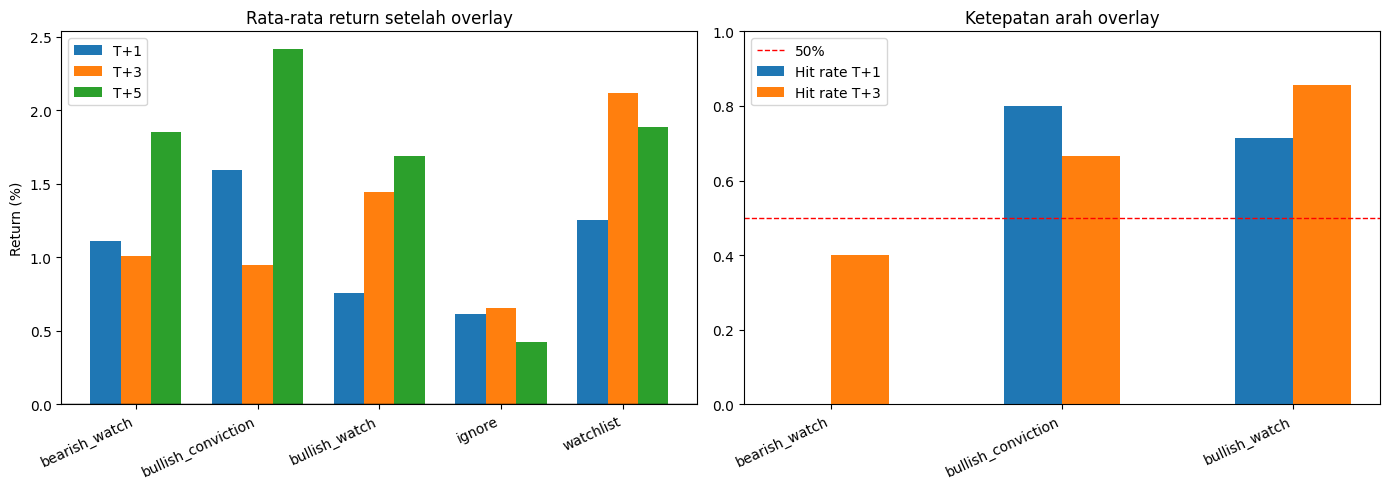

In [5]:
plot_roles = overlay_summary.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(plot_roles))
width = 0.25
axes[0].bar(x - width, plot_roles["mean_ret_t1_pct"], width=width, label="T+1")
axes[0].bar(x, plot_roles["mean_ret_t3_pct"], width=width, label="T+3")
axes[0].bar(x + width, plot_roles["mean_ret_t5_pct"], width=width, label="T+5")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xticks(x)
axes[0].set_xticklabels(plot_roles["overlay_role"], rotation=25, ha="right")
axes[0].set_title("Rata-rata return setelah overlay")
axes[0].set_ylabel("Return (%)")
axes[0].legend()

directional = plot_roles[plot_roles["overlay_role"].isin(["bullish_conviction", "bullish_watch", "bearish_caution", "bearish_watch"])].copy()
x2 = np.arange(len(directional))
axes[1].bar(x2 - width / 2, directional["hit_rate_t1"], width=width, label="Hit rate T+1")
axes[1].bar(x2 + width / 2, directional["hit_rate_t3"], width=width, label="Hit rate T+3")
axes[1].axhline(0.5, color="red", linestyle="--", linewidth=1, label="50%")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(directional["overlay_role"], rotation=25, ha="right")
axes[1].set_title("Ketepatan arah overlay")
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()


## Audit Artikel Pendukung per Hari

Bagian ini memudahkan pembacaan manusia. Jadi bukan hanya melihat angka rata-rata, tetapi juga berita apa yang membentuk overlay pada hari tersebut.


In [6]:
article_daily = (
    scored.sort_values(["news_date", "news_datetime"])
    .groupby("news_date")
    .agg(
        article_count=("article_id", "count"),
        labels=("impact_label", lambda x: ", ".join(sorted(set(x)))),
        channels=("impact_channel", lambda x: ", ".join(sorted(set(x)))),
        avg_score=("market_impact_score", "mean"),
        avg_confidence=("confidence", "mean"),
        sample_titles=("title", lambda x: " | ".join(x.head(3))),
    )
    .reset_index()
)

audit = (
    evaluation.merge(article_daily, on="news_date", how="left")
    .sort_values("news_date")
)

audit_cols = [
    "news_date",
    "overlay_role",
    "overlay_note",
    "dominant_channel",
    "article_count",
    "avg_score",
    "avg_confidence",
    "ret_t1_pct",
    "ret_t3_pct",
    "ret_t5_pct",
    "sample_titles",
]
display(audit[audit_cols])


,news_date,overlay_role,overlay_note,dominant_channel,article_count,avg_score,avg_confidence,ret_t1_pct,ret_t3_pct,ret_t5_pct,sample_titles
0,2025-09-22,bullish_watch,"News bullish ada, tetapi belum cukup kuat untu...",supply,1,0.60,0.700,-0.003261,0.008201,0.021045,Aluminium Years Of Plenty Are Drawing To A Clo...
1,2025-10-04,ignore,"Ada berita, tetapi sinyal terlalu lemah untuk ...",supply,1,0.20,0.400,0.009768,0.034708,0.006543,Việt Nam taps into aluminium surge amid global...
2,2025-10-07,ignore,"Ada berita, tetapi sinyal terlalu lemah untuk ...",macro,1,0.00,0.300,0.007231,-0.021976,-0.009767,Goldman Sachs hikes 2026 copper forecast to $1...
3,2025-10-13,bullish_conviction,News supply/logistics bullish yang kuat. Layak...,supply,1,0.70,0.850,-0.006595,0.012342,0.013473,U . S . Aluminum Prices Remain High After Nove...
4,2025-10-15,bearish_watch,"News bearish ada, tetapi belum cukup kuat untu...",logistics,1,-0.30,0.700,0.016364,0.017499,0.024593,UPS Erroneously Applies 200 % Russian Tariff t...
5,2025-10-22,bullish_watch,"News bullish ada, tetapi belum cukup kuat untu...",policy,1,0.60,0.800,0.022434,0.034066,0.044775,ALLEN WEST : Trump Aluminum And Steel Tariffs ...
6,2025-10-24,ignore,"Ada berita, tetapi sinyal terlalu lemah untuk ...",price,2,-0.20,0.775,0.008463,0.018907,0.017286,Japanese Q4 aluminum premium assessed down 20 ...
7,2025-10-31,bearish_watch,"News bearish ada, tetapi belum cukup kuat untu...",demand,1,-0.70,0.850,0.009735,-0.021949,-0.017612,Domestic Aluminum Rod Market Trapped in Oversu...
8,2025-11-11,bullish_watch,"News bullish ada, tetapi belum cukup kuat untu...",policy,1,0.90,0.950,0.010678,0.000179,-0.036612,U . S . Aluminum Prices Surge To Record Highs ...
9,2025-11-12,bullish_watch,"News bullish ada, tetapi belum cukup kuat untu...",policy,1,0.90,0.950,0.005061,-0.029655,-0.036314,Trump Tariffs Send U . S . Aluminum Prices to ...


## Kesimpulan Praktis

Bagian akhir ini tidak mencoba membuktikan bahwa news sudah siap menjadi feature model utama. Fokusnya lebih sempit:
- apakah **bullish overlay** mulai terlihat punya nilai pada event tertentu
- apakah **bearish overlay** cukup kuat untuk dipakai sebagai warning
- apakah data saat ini sudah cukup untuk integrasi model


In [7]:
directional = evaluation[evaluation["expected_sign"].notna()].copy()

final_rows = [
    {
        "Poin": "Ukuran sample",
        "Kesimpulan": "Masih pilot",
        "Catatan": f"{len(scored)} artikel, {len(overlay)} hari overlay.",
    },
    {
        "Poin": "Bullish overlay",
        "Kesimpulan": "Mulai menjanjikan",
        "Catatan": "Terutama jika channel dominan supply/logistics dan score harian cukup kuat.",
    },
    {
        "Poin": "Bearish overlay",
        "Kesimpulan": "Masih lemah",
        "Catatan": "Lebih cocok sebagai caution/size down, belum layak sebagai veto arah.",
    },
    {
        "Poin": "Penggunaan sekarang",
        "Kesimpulan": "Explanation + overlay konservatif",
        "Catatan": "Belum layak menjadi feature utama model harga.",
    },
    {
        "Poin": "Langkah berikutnya",
        "Kesimpulan": "Tambah sejarah data",
        "Catatan": "Perlu backfill lebih panjang atau rolling update harian sebelum uji model+overlay.",
    },
]

final_summary = pd.DataFrame(final_rows)
display(final_summary)


,Poin,Kesimpulan,Catatan
0,Ukuran sample,Masih pilot,"38 artikel, 30 hari overlay."
1,Bullish overlay,Mulai menjanjikan,Terutama jika channel dominan supply/logistics...
2,Bearish overlay,Masih lemah,"Lebih cocok sebagai caution/size down, belum l..."
3,Penggunaan sekarang,Explanation + overlay konservatif,Belum layak menjadi feature utama model harga.
4,Langkah berikutnya,Tambah sejarah data,Perlu backfill lebih panjang atau rolling upda...
